In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)

2.5.1
3.0.5


In [2]:
def col_stats(a_arr):
    d = np.mean(a_arr, axis=0)
    e = np.std(a_arr, axis=0)
    f = np.min(a_arr, axis=0)
    g = np.max(a_arr, axis=0)
    return d, e, f, g

def pair_dist(a_arr, b_arr):
    d = a_arr[:, np.newaxis, :]
    e = b_arr[np.newaxis, :, :]
    return np.sqrt(np.sum((d - e) ** 2, axis=-1))

def conf_mat_multi(a_true, b_pred):
    a_true = np.asarray(a_true)
    b_pred = np.asarray(b_pred)
    d = np.unique(np.concatenate((a_true, b_pred)))
    e = len(d)
    f = np.zeros((e, e), dtype=int)
    for g, h in enumerate(d):
        for i, j in enumerate(d):
            f[g, i] = np.sum((a_true == h) & (b_pred == j))
    return f, d

def bin_metrics(a_true, b_pred):
    a_true = np.asarray(a_true)
    b_pred = np.asarray(b_pred)
    d = np.sum((a_true == 1) & (b_pred == 1))
    e = np.sum((a_true == 0) & (b_pred == 1))
    f = np.sum((a_true == 1) & (b_pred == 0))
    g = d / (d + e) if (d + e) > 0 else 0.0
    h = d / (d + f) if (d + f) > 0 else 0.0
    i = (2 * g * h) / (g + h) if (g + h) > 0 else 0.0
    return g, h, i

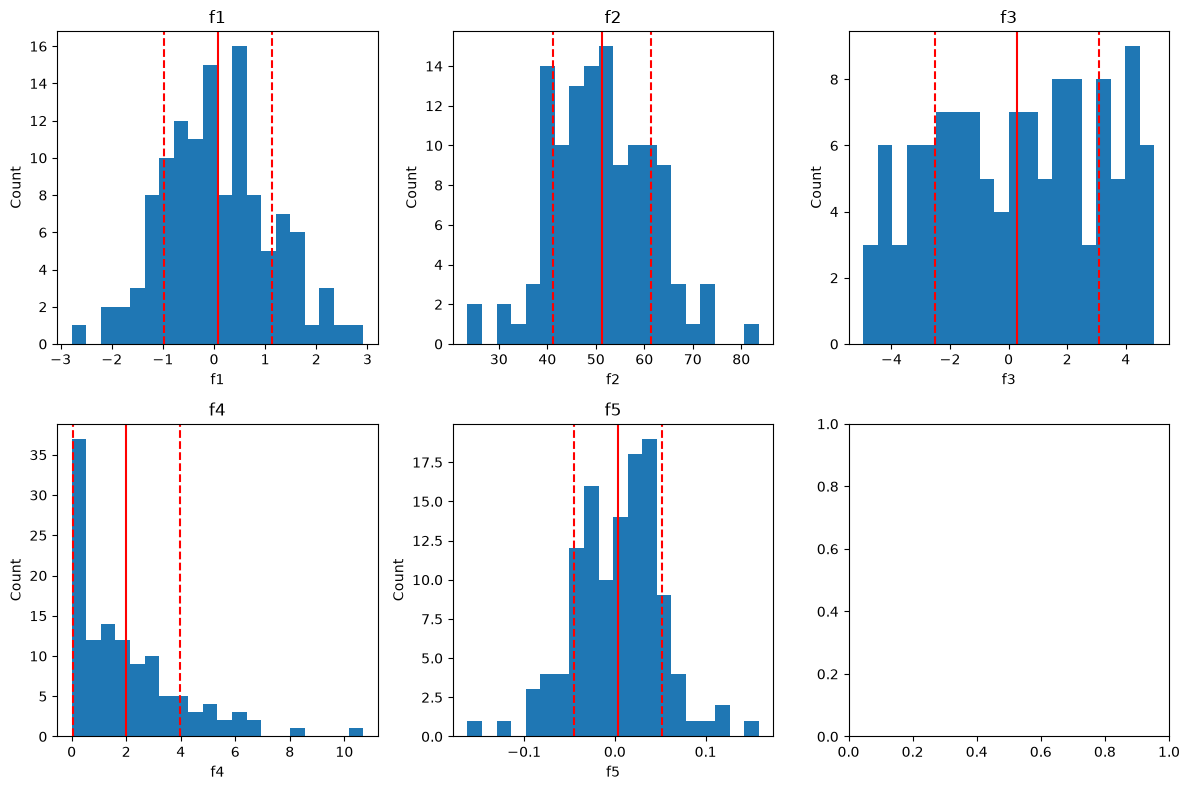

In [3]:
d = pd.read_csv("lab1_features.csv")
e, f = plt.subplots(2, 3, figsize=(12, 8))
g = f.flatten()
for h, i in enumerate(d.columns):
    j = d[i].values
    k, l, m, n = col_stats(j)
    g[h].hist(j, bins=20)
    g[h].axvline(k, color="red")
    
    g[h].axvline(k - l, color="red", linestyle="--")
    
    g[h].axvline(k + l, color="red", linestyle="--")
    
    g[h].set_xlabel(str(i))
    g[h].set_ylabel("Count")
    
    g[h].set_title(str(i))
plt.tight_layout()
plt.show()

In [4]:
d.head()

,f1,f2,f3,f4,f5
0,-0.7136,43.9184,0.3279,0.2002,0.0134
1,1.6248,26.3853,0.2420,0.3901,-0.1214
2,0.1761,40.0557,0.0086,2.1367,-0.0019
3,1.3590,56.8912,-1.9542,4.8096,0.0579
4,0.4035,49.5661,-1.9010,4.3185,0.0422


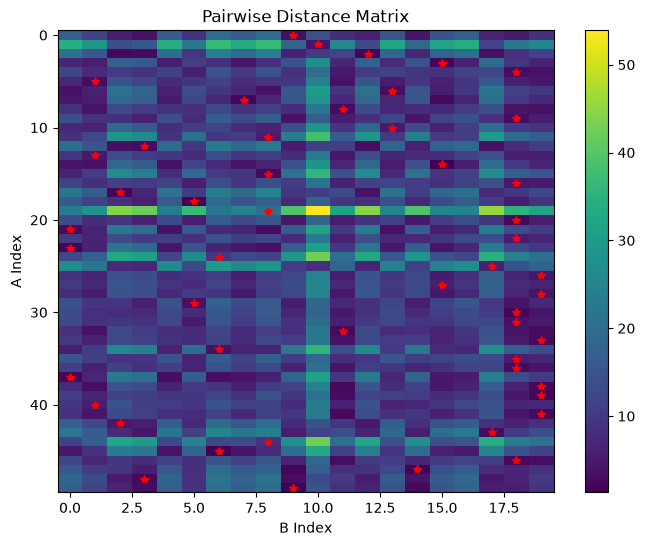

In [5]:
o = d.values
p = o[:50]
q = o[50:70]
r = pair_dist(p, q)
s, t = plt.subplots(figsize=(8, 6))

u = t.imshow(r, aspect="auto")
s.colorbar(u)


v = np.argmin(r, axis=1)

for w, x in enumerate(v):
    
    t.plot(x, w, "r*")
    
t.set_xlabel("B Index")
t.set_ylabel("A Index")
t.set_title("Pairwise Distance Matrix")
plt.show()

In [10]:
data_pred=pd.read_csv("lab1_predictions.csv")
data_pred.head()


,y_true_bin,y_pred_bin,y_true_multi,y_pred_multi
0,1,1,2,0
1,0,0,0,0
2,0,0,1,1
3,0,0,0,0
4,0,0,0,0


In [11]:
p1,p2=conf_mat_multi(data_pred['y_true_bin'],data_pred['y_pred_bin'])

In [13]:
print(p1)
print(p2)

[[342  18]
 [ 14  26]]
[0 1]


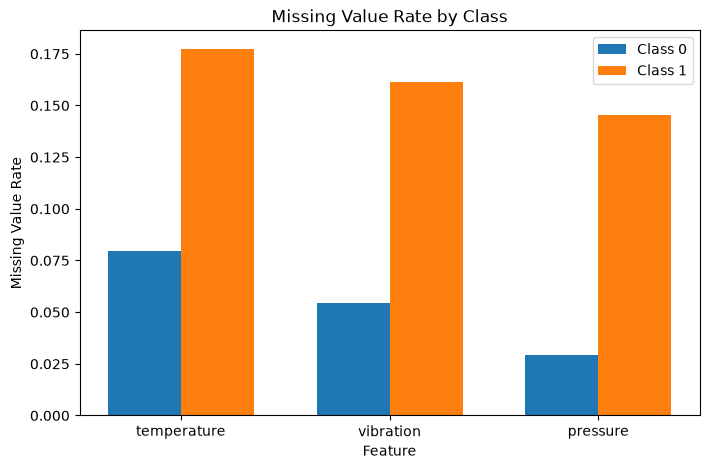

In [14]:
ai = pd.read_csv("lab2_machines.csv")
aj = ["temperature", "vibration", "pressure"]
ak = ai.groupby("needs_service")[aj].apply(lambda x: x.isna().mean())
al = np.arange(len(aj))
am = 0.35
an, ao = plt.subplots(figsize=(8, 5))
ao.bar(al - am/2, ak.loc[0], am, label="Class 0")
ao.bar(al + am/2, ak.loc[1], am, label="Class 1")

ao.set_xticks(al)
ao.set_xticklabels(aj)


ao.set_xlabel("Feature")

ao.set_ylabel("Missing Value Rate")
ao.set_title("Missing Value Rate by Class")
ao.legend()
plt.show()

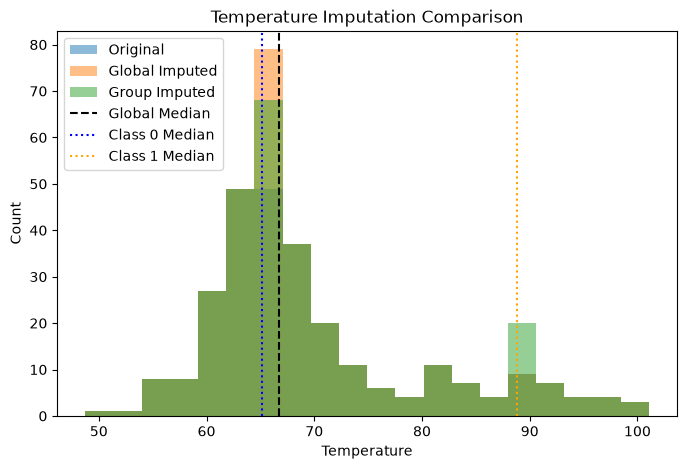

In [17]:
ap = ai["temperature"].dropna()
aq = ai["temperature"].median()
ar = ai["temperature"].fillna(aq)
as_val = ai.groupby("needs_service")["temperature"].transform("median")
at = ai["temperature"].fillna(as_val)
au, av = plt.subplots(figsize=(8, 5))
av.hist(ap, bins=20, alpha=0.5, label="Original")

av.hist(ar, bins=20, alpha=0.5, label="Global Imputed")
av.hist(at, bins=20, alpha=0.5, label="Group Imputed")
av.axvline(aq, color="black", linestyle="--", label="Global Median")

aw = ai.groupby("needs_service")["temperature"].median()
av.axvline(aw[0], color="blue", linestyle=":", label="Class 0 Median")
av.axvline(aw[1], color="orange", linestyle=":", label="Class 1 Median")
av.set_xlabel("Temperature")

av.set_ylabel("Count")


av.set_title("Temperature Imputation Comparison")
av.legend()
plt.show()

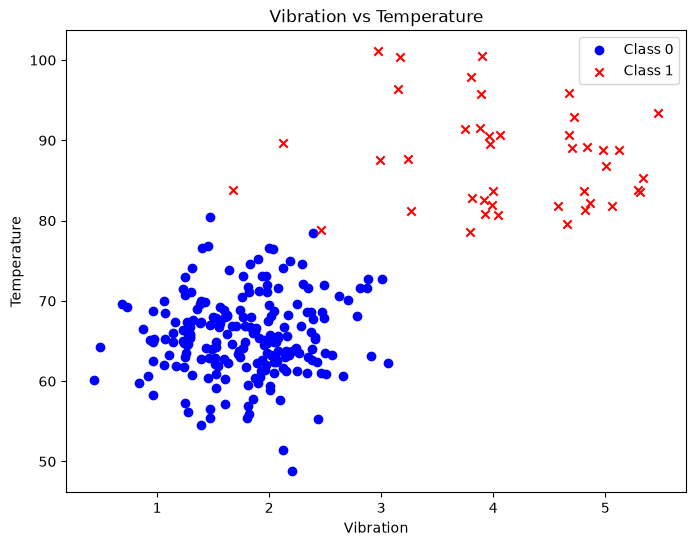

In [21]:
ax_fig, ay = plt.subplots(figsize=(8, 6))
az = ai[ai["needs_service"] == 0]
ba = ai[ai["needs_service"] == 1]
ay.scatter(az["vibration"], az["temperature"], c="blue", marker="o", label="Class 0")
ay.scatter(ba["vibration"], ba["temperature"], c="red", marker="x", label="Class 1")
ay.set_xlabel("Vibration")
ay.set_ylabel("Temperature")
ay.set_title("Vibration vs Temperature")
ay.legend()
plt.show()

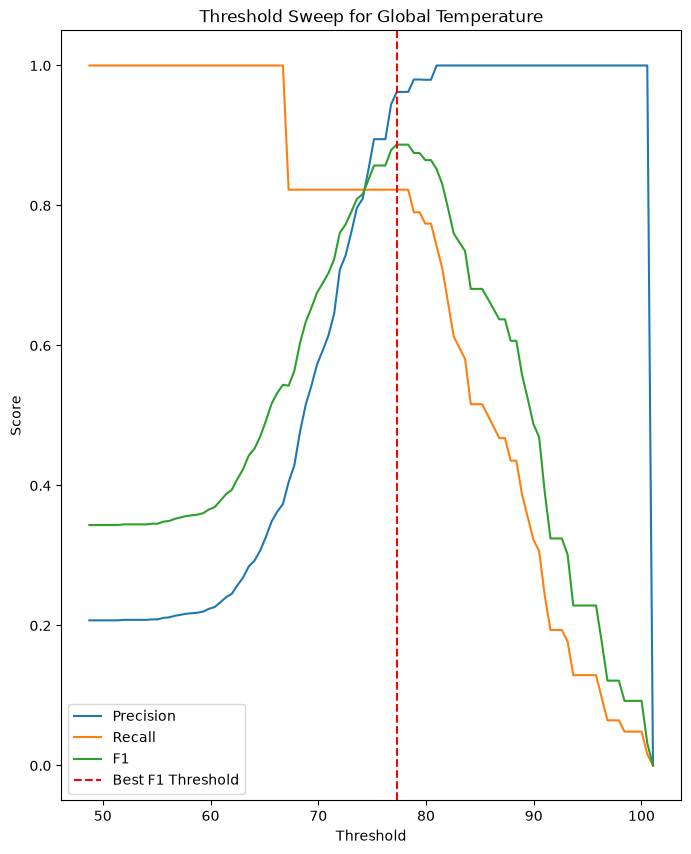

In [32]:
bb = np.linspace(ar.min(), ar.max(), 100)
bc = ai["needs_service"].values
bd, be, bf = [], [], []
for bg in bb:
    bh = (ar.values > bg).astype(int)

    bi, bj, bk = bin_metrics(bc, bh)
    bd.append(bi)
    be.append(bj)
    bf.append(bk)
bl = bb[np.argmax(bf)]
bm, bn = plt.subplots(figsize=(8, 10))
bn.plot(bb, bd, label="Precision")
bn.plot(bb, be, label="Recall")
bn.plot(bb, bf, label="F1")
bn.axvline(bl, color="red", linestyle="--", label="Best F1 Threshold")
bn.set_xlabel("Threshold")
bn.set_ylabel("Score")
bn.set_title("Threshold Sweep for Global Temperature")
bn.legend()
plt.show()

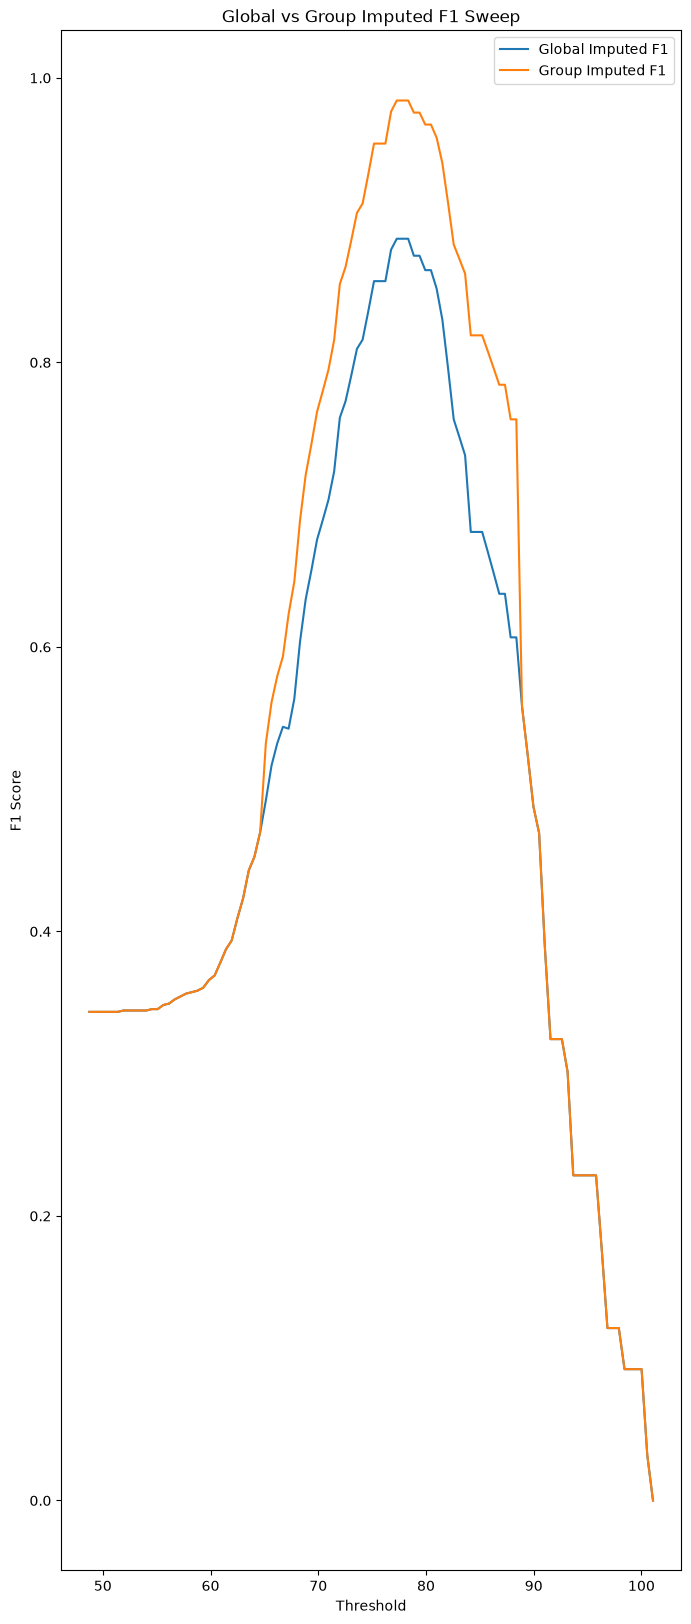

In [31]:
bo = []
for bg in bb:
    bh = (at.values > bg).astype(int)
    _, _, bk = bin_metrics(bc, bh)
    bo.append(bk)
bp, bq = plt.subplots(figsize=(8, 20))
bq.plot(bb, bf, label="Global Imputed F1")
bq.plot(bb, bo, label="Group Imputed F1")
bq.set_xlabel("Threshold")
bq.set_ylabel("F1 Score")
bq.set_title("Global vs Group Imputed F1 Sweep")
bq.legend()
plt.show()

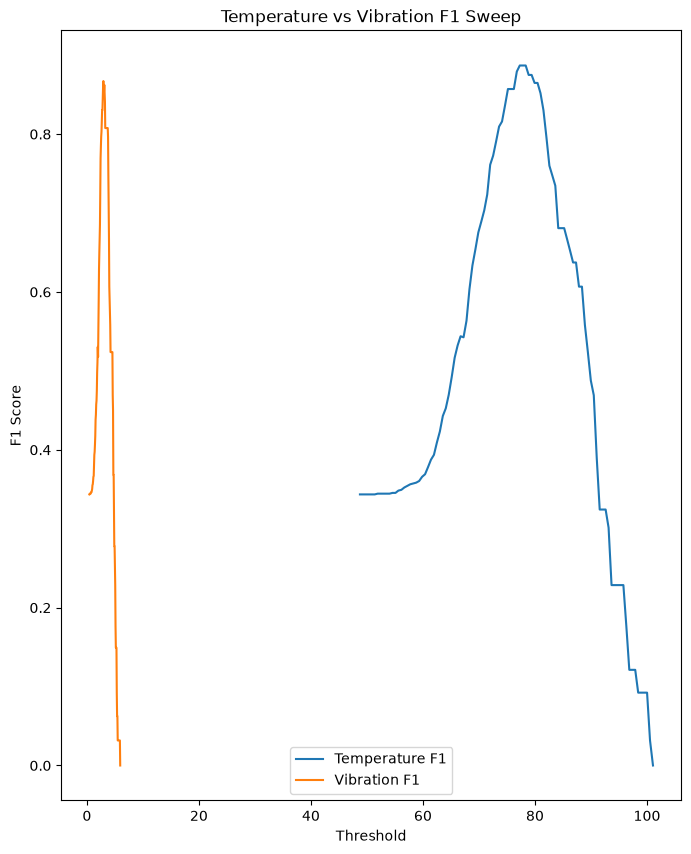

In [33]:
br = ai["vibration"].fillna(ai["vibration"].median())
bs = np.linspace(br.min(), br.max(), 100)
bt = []
for bg in bs:
    bh = (br.values > bg).astype(int)
    _, _, bk = bin_metrics(bc, bh)
    bt.append(bk)
bu, bv = plt.subplots(figsize=(8, 10))
bv.plot(bb, bf, label="Temperature F1")
bv.plot(bs, bt, label="Vibration F1")
bv.set_xlabel("Threshold")
bv.set_ylabel("F1 Score")
bv.set_title("Temperature vs Vibration F1 Sweep")
bv.legend()
plt.show()